# 4.2 — Les modèles basés sur les arbres

Cette famille regroupe les algorithmes qui raisonnent sous forme d'**arbres de décision**. Puisqu'ils évaluent nos critères par des paliers ou des seuils (ex: la surface est-elle supérieure à 150m² ?), la taille des nombres n'a absolument aucun impact sur leur logique. → Nous utilisons donc une préparation des données adaptée (`preprocessor_encoded`) qui saute l'étape de remise à l'échelle, devenue totalement inutile.

| Modèle              | Principe de fonctionnement                                                                                   |
|---------------------|--------------------------------------------------------------------------------------------------------------|
| Arbre de décision   | Crée des règles de découpage successives, mais a une forte tendance à apprendre nos données "par cœur".      |
| Random Forest       | Crée une grande "forêt" d'arbres indépendants qui votent ensemble pour rendre l'estimation finale très stable. |
| Gradient Boosting   | Travail d'équipe : chaque nouvel arbre est créé spécifiquement pour corriger les erreurs de l'arbre précédent. |
| AdaBoost            | Se concentre de plus en plus sur les maisons les plus dures à estimer, mais se laisse facilement tromper par des données aberrantes. |

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
Variables après ingénierie : 90 colonnes (+8 dérivées)
Corrélation des variables dérivées avec SalePrice_log :
  TotalSF            : +0.825
  TotalBathrooms     : +0.677
  HouseAge           : -0.588
  YearsSinceRemodel  : -0.569
  GarageAge          : -0.543
  HasGarage          : +0.323
  HasSecondFloor     : +0.151
  HasPool            : +0.077   <-- faible (|r| < 0.1)
X_train : (1166, 83)   |   X_test : (292, 83)
Colonnes retirées (colinéarité) : ['GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd', 'GarageYrBlt']
NaN dans X_train : 6276 cellules sur 96778
Audit de cardinalité des colonnes nominales (sur X_train) :
Colonne           modalités   bucket
  Neighborhood           25     TargetEncoder (haute)  [imput. mode]
  Exterior2nd            16     TargetEncoder (haute)  [imput. mode]
  Exterior1st            15     TargetEncoder (haute)  [imput. mode]
  MSSubClass             15     

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

FAMILY = 'sklearn_trees'

## 4.2.1 Arbre de Décision — avec contrôle du surapprentissage

### Principe et conditions d'utilisation
- **Aucune équation mathématique rigide** : l'algorithme procède par tris successifs (ex: la surface est-elle > 150m² ? oui/non) et peut théoriquement tout deviner s'il a le droit de poser suffisamment de questions.
- L'idée de base est que le marché immobilier peut s'expliquer par une série de **règles simples "si / alors"**.
- **Forte tendance à apprendre par cœur** : si on ne le limite pas dans le nombre de questions qu'il peut poser, l'arbre finit par mémoriser nos maisons d'exemple au lieu de déduire des règles générales.

Nous testons plusieurs niveaux de profondeur (le nombre de questions successives autorisées) et traçons un graphique comparant son score d'apprentissage à sa véritable capacité de prédiction, afin de lui trouver la taille idéale.

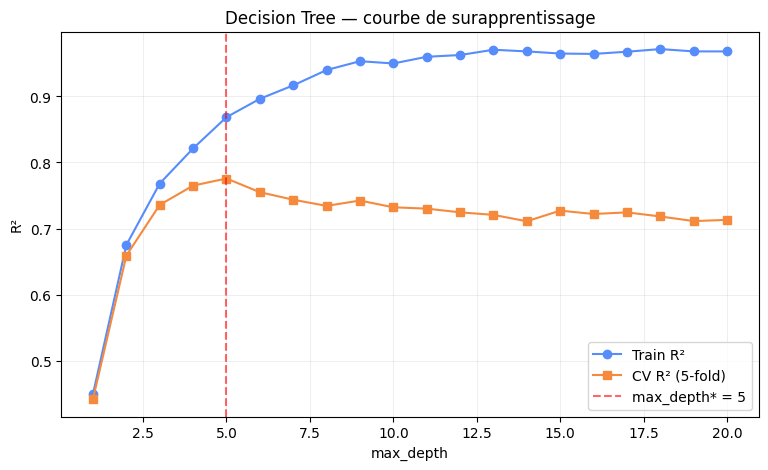

Profondeur optimale (CV R² max) : 5
L'écart train-vs-CV à droite illustre le surapprentissage : à max_depth élevé, le train R² → 1 mais le CV R² stagne / décroît.


In [3]:
depth_range = list(range(1, 21))
train_scores, cv_scores = [], []

for d in depth_range:
    pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train_log)
    train_scores.append(pipe.score(X_train, y_train_log))
    cv_scores.append(cross_val_score(pipe, X_train, y_train_log, cv=5, scoring='r2', n_jobs=-1).mean())

best_depth = int(depth_range[int(np.argmax(cv_scores))])

plt.figure(figsize=(9, 5))
plt.plot(depth_range, train_scores, marker='o', label='Train R²')
plt.plot(depth_range, cv_scores, marker='s', label='CV R² (5-fold)')
plt.axvline(best_depth, color='red', ls='--', alpha=0.6, label=f'max_depth* = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Decision Tree — courbe de surapprentissage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Profondeur optimale (CV R² max) : {best_depth}")
print(f"L'écart train-vs-CV à droite illustre le surapprentissage : à max_depth élevé, le train R² → 1 mais le CV R² stagne / décroît.")

DecisionTree — CV RMSLE: 0.1870   Holdout RMSLE: 0.1798   max_depth: 5   fit_time: 0.07s


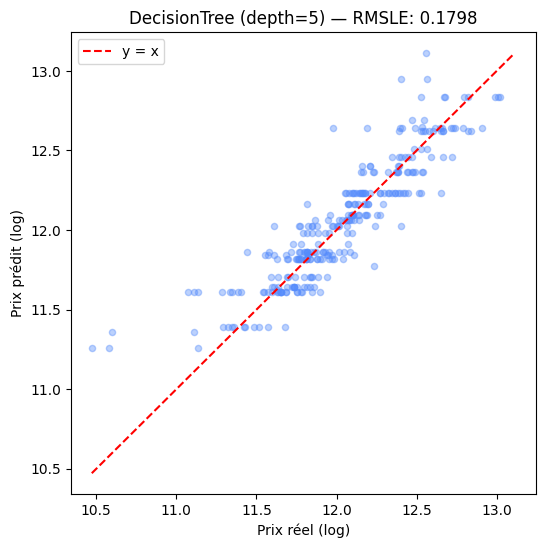

WindowsPath('results/family_sklearn_trees.json')

In [4]:
t0 = time.time()
dt_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))])
dt_pipe.fit(X_train, y_train_log)
dt_fit_s = time.time() - t0
dt_pred = dt_pipe.predict(X_test)
dt_holdout = rmsle_score(y_test_log, dt_pred)
dt_cv = cv_rmsle(dt_pipe, X_train, y_train_log)

print(f"DecisionTree — CV RMSLE: {dt_cv:.4f}   Holdout RMSLE: {dt_holdout:.4f}   max_depth: {best_depth}   fit_time: {dt_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, dt_pred, title=f"DecisionTree (depth={best_depth}) — RMSLE: {dt_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'DecisionTree', cv_rmsle=dt_cv, holdout_rmsle=dt_holdout, fit_time_s=dt_fit_s, params={'max_depth': best_depth})

## 4.2.2 Random Forest — La force du collectif (Forêt Aléatoire)

### Principe et conditions d'utilisation
- **Le principe du vote de groupe** : faire la moyenne des estimations de très nombreux arbres de décision indépendants permet de stabiliser considérablement notre marge d'erreur, sans perdre en précision.
- Cette indépendance (pour éviter qu'ils ne se copient) est garantie par deux règles : chaque arbre s'entraîne sur un échantillon différent de maisons, et n'a le droit d'examiner qu'une petite sélection de critères à chaque étape.
- Il est très résistant face aux maisons aux prix aberrants et ne se laisse absolument pas distraire par les critères inutiles de notre jeu de données.
- **Sa limite** : ce groupe d'arbres ne fera pas de miracles pour détecter des logiques de marché extrêmement complexes — pour franchir ce cap, il faut passer à un apprentissage correctif (le **Boosting**).

RandomForest — CV RMSLE: 0.1369   Holdout RMSLE: 0.1375   fit_time: 1.48s


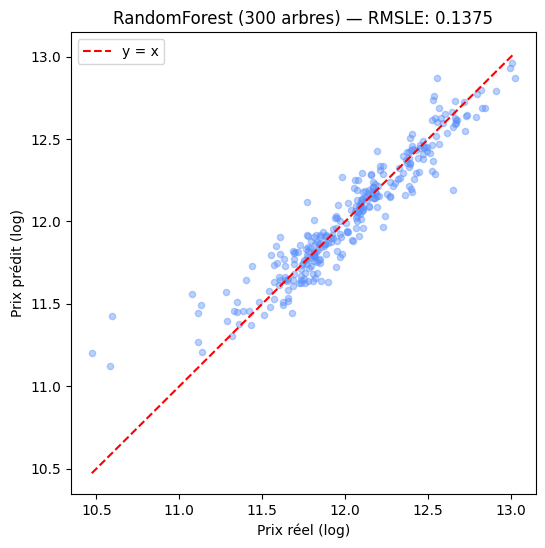

WindowsPath('results/family_sklearn_trees.json')

In [5]:
t0 = time.time()
rf_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_train, y_train_log)
rf_fit_s = time.time() - t0
rf_pred = rf_pipe.predict(X_test)
rf_holdout = rmsle_score(y_test_log, rf_pred)
rf_cv = cv_rmsle(rf_pipe, X_train, y_train_log)

print(f"RandomForest — CV RMSLE: {rf_cv:.4f}   Holdout RMSLE: {rf_holdout:.4f}   fit_time: {rf_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, rf_pred, title=f"RandomForest (300 arbres) — RMSLE: {rf_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'RandomForest', cv_rmsle=rf_cv, holdout_rmsle=rf_holdout, fit_time_s=rf_fit_s, params={'n_estimators': 300})

## 4.2.3 Gradient Boosting — L'apprentissage par correction

### Principe et conditions d'utilisation
- **Le principe du travail à la chaîne** : au lieu de faire voter les arbres de manière indépendante, ici ils travaillent à la suite. Chaque nouvel arbre se concentre exclusivement sur les erreurs (les "restes" inexpliqués) laissées par les arbres précédents pour les corriger.
- Ce modèle combine une excellente capacité à trouver des logiques très pointues (en empilant les corrections) tout en restant stable (en freinant volontairement sa vitesse d'apprentissage).
- Il est beaucoup plus "capricieux" que la Forêt Aléatoire : l'équilibre entre sa force de correction et le nombre d'arbres ajoutés doit être parfaitement dosé, sous peine de détériorer la prédiction.
- Il prend logiquement plus de temps à s'entraîner, mais c'est souvent l'algorithme le plus performant à la fin.

GradientBoosting — CV RMSLE: 0.1252   Holdout RMSLE: 0.1154   fit_time: 2.13s


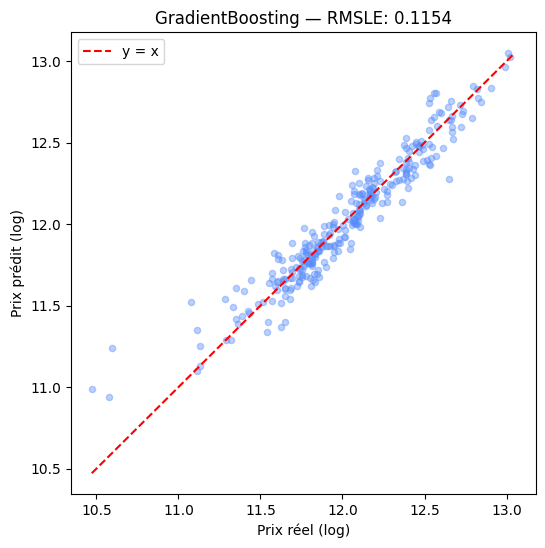

WindowsPath('results/family_sklearn_trees.json')

In [6]:
t0 = time.time()
gb_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE))])
gb_pipe.fit(X_train, y_train_log)
gb_fit_s = time.time() - t0
gb_pred = gb_pipe.predict(X_test)
gb_holdout = rmsle_score(y_test_log, gb_pred)
gb_cv = cv_rmsle(gb_pipe, X_train, y_train_log)

print(f"GradientBoosting — CV RMSLE: {gb_cv:.4f}   Holdout RMSLE: {gb_holdout:.4f}   fit_time: {gb_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, gb_pred, title=f"GradientBoosting — RMSLE: {gb_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'GradientBoosting', cv_rmsle=gb_cv, holdout_rmsle=gb_holdout, fit_time_s=gb_fit_s,
               params={'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3})

## 4.2.4 AdaBoost — L'apprentissage par insistance

### Principe et conditions d'utilisation
- **Le principe d'attention aux erreurs** : à chaque nouvelle tentative, l'algorithme accorde une importance de plus en plus grande aux maisons sur lesquelles il s'est trompé précédemment.
- C'est l'ancêtre historique de ces méthodes correctives développé bien avant le Gradient Boosting.
- **Vulnérabilité aux anomalies (cas extrêmes)** : l'algorithme s'obstine tellement sur les maisons atypiques (qui sont parfois juste des exceptions illogiques, et non une règle de marché) qu'il finit par se dérégler en essayant de leur inventer une explication artificielle.
- Notre nettoyage initial des maisons aux prix aberrants limite heureusement ce danger, mais cet algorithme reste globalement moins efficace que le Gradient Boosting pour notre objectif.

AdaBoost — CV RMSLE: 0.1593   Holdout RMSLE: 0.1697   fit_time: 1.34s


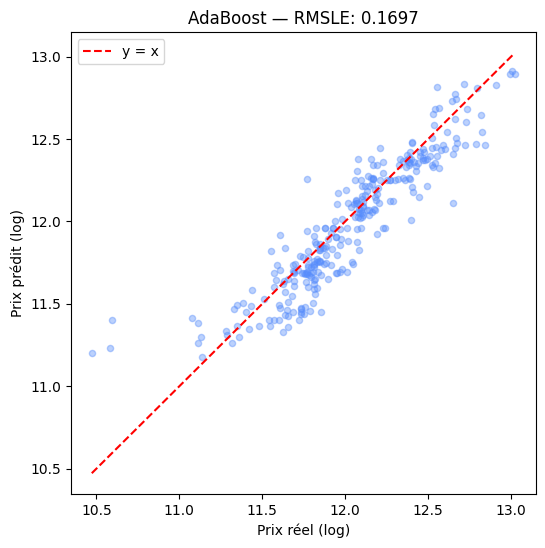

WindowsPath('results/family_sklearn_trees.json')

In [7]:
t0 = time.time()
ada_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE))])
ada_pipe.fit(X_train, y_train_log)
ada_fit_s = time.time() - t0
ada_pred = ada_pipe.predict(X_test)
ada_holdout = rmsle_score(y_test_log, ada_pred)
ada_cv = cv_rmsle(ada_pipe, X_train, y_train_log)

print(f"AdaBoost — CV RMSLE: {ada_cv:.4f}   Holdout RMSLE: {ada_holdout:.4f}   fit_time: {ada_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ada_pred, title=f"AdaBoost — RMSLE: {ada_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'AdaBoost', cv_rmsle=ada_cv, holdout_rmsle=ada_holdout, fit_time_s=ada_fit_s, params={'n_estimators': 200})

## 4.2.5 Bilan et choix du champion de cette catégorie

Nous comparons la précision de nos différents arbres de décision pour élire le **champion de cette famille**. Notre recherche se poursuivra ensuite avec la **nouvelle génération d'algorithmes correctifs** (`3c` : XGBoost, LightGBM, CatBoost) — des modèles modernes et surpuissants capables de gérer intelligemment les "trous" dans nos données et de lire directement du texte (comme le nom d'un quartier) sans que nous ayons besoin de le transformer en chiffres au préalable.

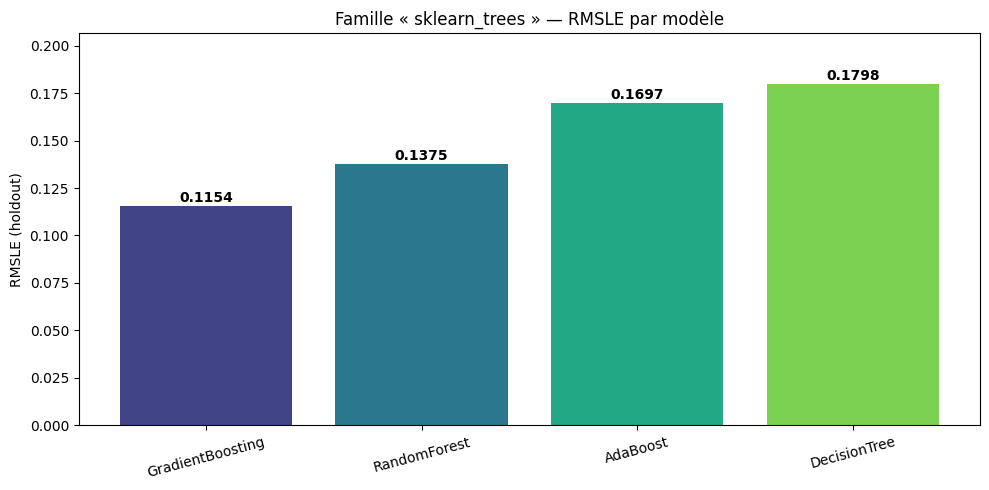

,model,cv_rmsle,holdout_rmsle,fit_time_s
0,GradientBoosting,0.125168,0.115419,2.130165
1,RandomForest,0.136903,0.137526,1.478921
2,AdaBoost,0.159294,0.169745,1.336089
3,DecisionTree,0.187021,0.179759,0.068793


In [8]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))
fam = fam.sort_values('holdout_rmsle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « sklearn_trees » — RMSLE par modèle")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

In [9]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    DecisionTree=dt_pred, RandomForest=rf_pred,
    GradientBoosting=gb_pred, AdaBoost=ada_pred,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results\preds_sklearn_trees.npz
